In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia/sch/586w1.eea
/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia/sch/S084-1W.eea
/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia/sch/342mw1.eea
/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia/sch/r229w1.eea
/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia/sch/382w1.eea
/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia/sch/192w.eea
/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia/sch/s083w1.eea
/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia/sch/573w1.eea
/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia/sch/387-02w1.eea
/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia/sch/s425w1.eea
/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia/sch/575w1.eea
/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia/sch/454-1W

In [2]:
!pip install mne pywavelets

In [3]:
import os
import numpy as np
import pandas as pd

from scipy.signal import butter, filtfilt

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

In [4]:
BASE_PATH = "/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia"

SCH_PATH = os.path.join(BASE_PATH, "sch")
NORM_PATH = os.path.join(BASE_PATH, "norm")

In [5]:
print("Schizophrenia Files:", len(os.listdir(SCH_PATH)))
print("Healthy Files:", len(os.listdir(NORM_PATH)))

Schizophrenia Files: 45
Healthy Files: 39


In [6]:
def read_eeg_file(filepath):

    try:
        data = np.loadtxt(filepath)
        return data

    except Exception as e:
        print("Error:", e)
        return None

In [7]:
sample_file = os.path.join(SCH_PATH, os.listdir(SCH_PATH)[0])

eeg = read_eeg_file(sample_file)

print(type(eeg))

if eeg is not None:
    print(eeg.shape)
    print(eeg[:5])

<class 'numpy.ndarray'>
(122880,)
[-570.29 -693.3  -633.66 -510.65 -451.02]


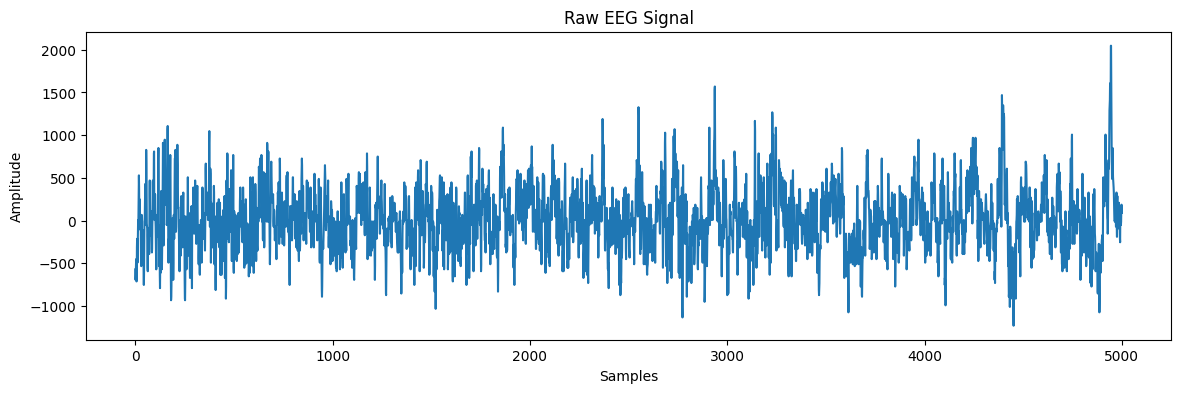

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))

plt.plot(eeg[:5000])

plt.title("Raw EEG Signal")

plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [9]:
from scipy.signal import butter, filtfilt

def butter_bandpass(lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    return b, a


def bandpass_filter(data, lowcut=0.5, highcut=40, fs=250):

    b, a = butter_bandpass(lowcut, highcut, fs)

    filtered = filtfilt(b, a, data)

    return filtered

In [10]:
filtered_eeg = bandpass_filter(eeg)

print(filtered_eeg.shape)

(122880,)


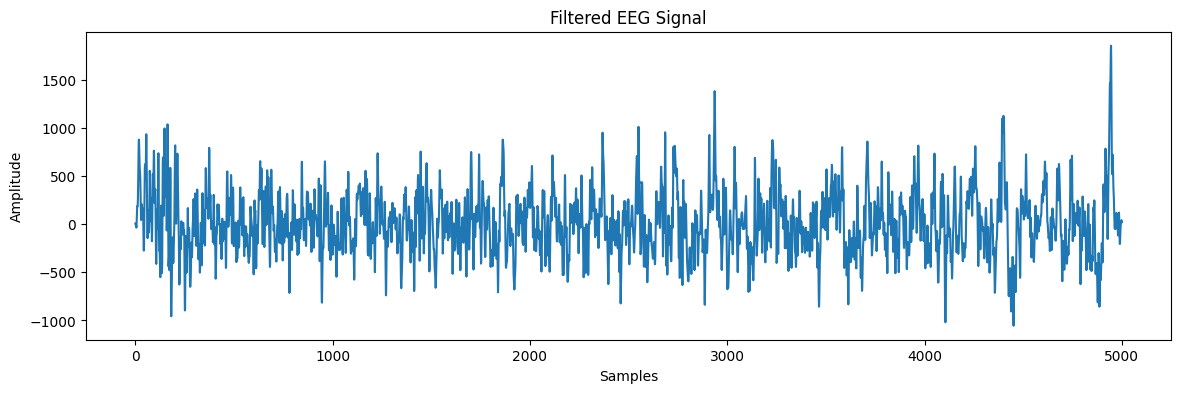

In [11]:
plt.figure(figsize=(14,4))

plt.plot(filtered_eeg[:5000])

plt.title("Filtered EEG Signal")

plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [12]:
window_size = 2500

segments = []

for i in range(0, len(filtered_eeg) - window_size, window_size):

    segment = filtered_eeg[i:i+window_size]

    segments.append(segment)

segments = np.array(segments)

print("Segments Shape:", segments.shape)

Segments Shape: (49, 2500)


In [13]:
def differential_entropy(signal):

    variance = np.var(signal)

    if variance <= 0:
        variance = 1e-8

    de = 0.5 * np.log(2 * np.pi * np.e * variance)

    return de

In [14]:
de_features = []

for seg in segments:

    de = differential_entropy(seg)

    de_features.append(de)

de_features = np.array(de_features)

print("DE Features Shape:", de_features.shape)

print(de_features[:10])

DE Features Shape: (49,)
[7.08635219 7.27990732 7.11921701 7.13614656 7.0472754  7.11145001
 7.08864809 7.13040186 7.11375372 7.10664549]


In [15]:
X = []
y = []

In [16]:
for file in os.listdir(SCH_PATH):

    filepath = os.path.join(SCH_PATH, file)

    eeg = read_eeg_file(filepath)

    if eeg is None:
        continue

    eeg = eeg.flatten()

    eeg = bandpass_filter(eeg)

    # Segmentation
    segments = []

    for i in range(0, len(eeg) - window_size, window_size):

        segment = eeg[i:i+window_size]

        segments.append(segment)

    # DE extraction
    de_vals = []

    for seg in segments:

        de = differential_entropy(seg)

        de_vals.append(de)

    # Mean DE feature
    mean_de = np.mean(de_vals)

    X.append([mean_de])

    y.append(1)

In [17]:
for file in os.listdir(NORM_PATH):

    filepath = os.path.join(NORM_PATH, file)

    eeg = read_eeg_file(filepath)

    if eeg is None:
        continue

    eeg = eeg.flatten()

    eeg = bandpass_filter(eeg)

    segments = []

    for i in range(0, len(eeg) - window_size, window_size):

        segment = eeg[i:i+window_size]

        segments.append(segment)

    de_vals = []

    for seg in segments:

        de = differential_entropy(seg)

        de_vals.append(de)

    mean_de = np.mean(de_vals)

    X.append([mean_de])

    y.append(0)

Schizophrenia Files: 45
Healthy Files: 39

Feature Shape: (84, 1)
Label Shape: (84,)


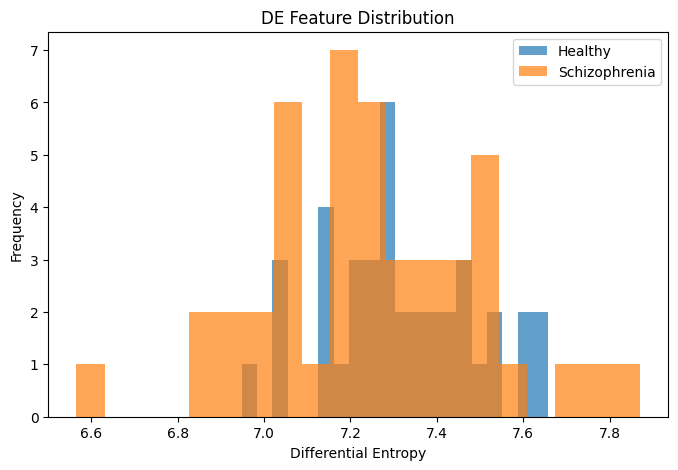


Training Samples: 67
Testing Samples: 17

CLASSIFICATION RESULTS

Accuracy: 0.47058823529411764

Classification Report:

              precision    recall  f1-score   support

           0       0.46      0.75      0.57         8
           1       0.50      0.22      0.31         9

    accuracy                           0.47        17
   macro avg       0.48      0.49      0.44        17
weighted avg       0.48      0.47      0.43        17


Confusion Matrix:

[[6 2]
 [7 2]]


In [18]:
# =========================================================
# EEG SCHIZOPHRENIA CLASSIFICATION PIPELINE
# Differential Entropy + SVM
# =========================================================

# ======================
# 1. IMPORT LIBRARIES
# ======================

import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ======================
# 2. DATASET PATHS
# ======================

BASE_PATH = "/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia"

SCH_PATH = os.path.join(BASE_PATH, "sch")
NORM_PATH = os.path.join(BASE_PATH, "norm")

print("Schizophrenia Files:", len(os.listdir(SCH_PATH)))
print("Healthy Files:", len(os.listdir(NORM_PATH)))

# ======================
# 3. READ EEG FILE
# ======================

def read_eeg_file(filepath):

    try:
        data = np.loadtxt(filepath)
        return data

    except Exception as e:
        print("Error reading:", filepath)
        print(e)
        return None

# ======================
# 4. BANDPASS FILTER
# ======================

def butter_bandpass(lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    return b, a


def bandpass_filter(data, lowcut=0.5, highcut=40, fs=250):

    b, a = butter_bandpass(lowcut, highcut, fs)

    filtered = filtfilt(b, a, data)

    return filtered

# ======================
# 5. DIFFERENTIAL ENTROPY
# ======================

def differential_entropy(signal):

    variance = np.var(signal)

    if variance <= 0:
        variance = 1e-8

    de = 0.5 * np.log(2 * np.pi * np.e * variance)

    return de

# ======================
# 6. WINDOW PARAMETERS
# ======================

window_size = 2500

# ======================
# 7. BUILD DATASET
# ======================

X = []
y = []

# -----------------------------------
# SCHIZOPHRENIA SUBJECTS
# -----------------------------------

for file in os.listdir(SCH_PATH):

    filepath = os.path.join(SCH_PATH, file)

    eeg = read_eeg_file(filepath)

    if eeg is None:
        continue

    eeg = eeg.flatten()

    # Filter EEG
    eeg = bandpass_filter(eeg)

    # Segment EEG
    segments = []

    for i in range(0, len(eeg) - window_size, window_size):

        segment = eeg[i:i+window_size]

        segments.append(segment)

    # DE Feature Extraction
    de_vals = []

    for seg in segments:

        de = differential_entropy(seg)

        de_vals.append(de)

    # Mean DE feature
    mean_de = np.mean(de_vals)

    X.append([mean_de])

    y.append(1)

# -----------------------------------
# HEALTHY SUBJECTS
# -----------------------------------

for file in os.listdir(NORM_PATH):

    filepath = os.path.join(NORM_PATH, file)

    eeg = read_eeg_file(filepath)

    if eeg is None:
        continue

    eeg = eeg.flatten()

    eeg = bandpass_filter(eeg)

    segments = []

    for i in range(0, len(eeg) - window_size, window_size):

        segment = eeg[i:i+window_size]

        segments.append(segment)

    de_vals = []

    for seg in segments:

        de = differential_entropy(seg)

        de_vals.append(de)

    mean_de = np.mean(de_vals)

    X.append([mean_de])

    y.append(0)

# ======================
# 8. CONVERT TO NUMPY
# ======================

X = np.array(X)
y = np.array(y)

print("\nFeature Shape:", X.shape)
print("Label Shape:", y.shape)

# ======================
# 9. VISUALIZE FEATURES
# ======================

plt.figure(figsize=(8,5))

plt.hist(X[y==0], bins=20, alpha=0.7, label='Healthy')
plt.hist(X[y==1], bins=20, alpha=0.7, label='Schizophrenia')

plt.xlabel("Differential Entropy")
plt.ylabel("Frequency")
plt.title("DE Feature Distribution")

plt.legend()

plt.show()

# ======================
# 10. TRAIN-TEST SPLIT
# ======================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# ======================
# 11. SVM CLASSIFIER
# ======================

model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# ======================
# 12. EVALUATION
# ======================

acc = accuracy_score(y_test, y_pred)

print("\n=====================")
print("CLASSIFICATION RESULTS")
print("=====================")

print("\nAccuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Schizophrenia Files: 45
Healthy Files: 39

Feature Shape: (84, 49)
Label Shape: (84,)


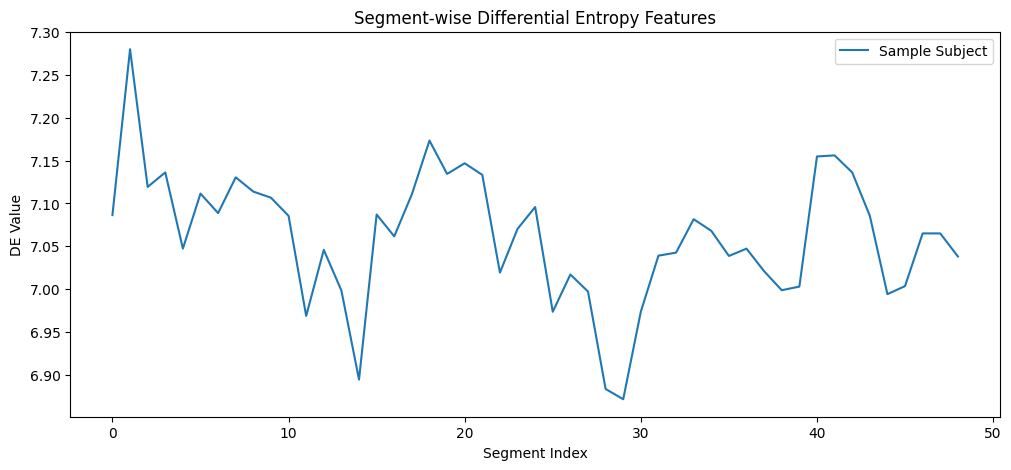


Training Samples: 67
Testing Samples: 17

CLASSIFICATION RESULTS

Accuracy: 0.5882352941176471

Classification Report:

              precision    recall  f1-score   support

           0       0.55      0.75      0.63         8
           1       0.67      0.44      0.53         9

    accuracy                           0.59        17
   macro avg       0.61      0.60      0.58        17
weighted avg       0.61      0.59      0.58        17


Confusion Matrix:

[[6 2]
 [5 4]]


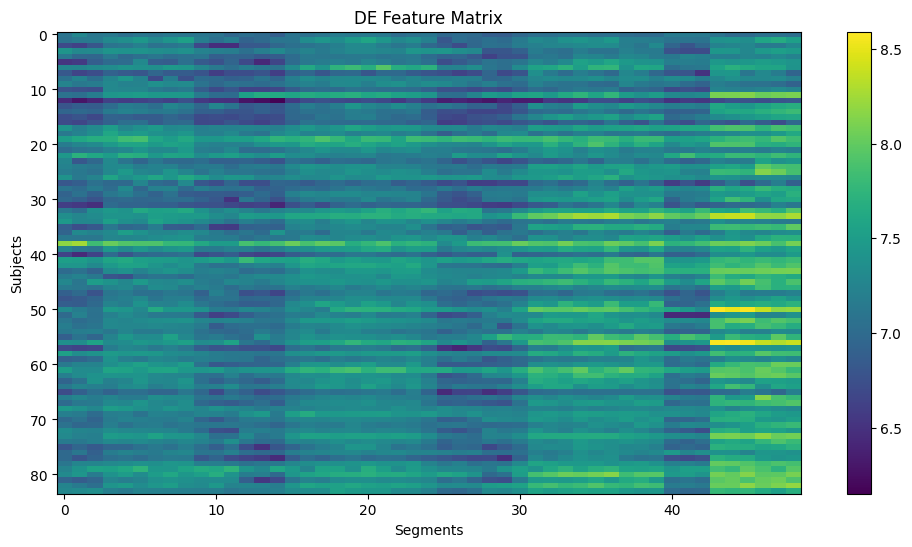

In [19]:
# =========================================================
# IMPROVED EEG SCHIZOPHRENIA CLASSIFICATION
# Segment-wise Differential Entropy + SVM
# =========================================================

# ======================
# 1. IMPORT LIBRARIES
# ======================

import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ======================
# 2. DATASET PATHS
# ======================

BASE_PATH = "/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia"

SCH_PATH = os.path.join(BASE_PATH, "sch")
NORM_PATH = os.path.join(BASE_PATH, "norm")

print("Schizophrenia Files:", len(os.listdir(SCH_PATH)))
print("Healthy Files:", len(os.listdir(NORM_PATH)))

# ======================
# 3. READ EEG FILE
# ======================

def read_eeg_file(filepath):

    try:
        data = np.loadtxt(filepath)
        return data

    except Exception as e:
        print("Error reading:", filepath)
        print(e)
        return None

# ======================
# 4. BANDPASS FILTER
# ======================

def butter_bandpass(lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    return b, a


def bandpass_filter(data, lowcut=0.5, highcut=40, fs=250):

    b, a = butter_bandpass(lowcut, highcut, fs)

    filtered = filtfilt(b, a, data)

    return filtered

# ======================
# 5. DIFFERENTIAL ENTROPY
# ======================

def differential_entropy(signal):

    variance = np.var(signal)

    if variance <= 0:
        variance = 1e-8

    de = 0.5 * np.log(2 * np.pi * np.e * variance)

    return de

# ======================
# 6. WINDOW PARAMETERS
# ======================

window_size = 2500

# ======================
# 7. BUILD DATASET
# ======================

X = []
y = []

# -----------------------------------
# SCHIZOPHRENIA SUBJECTS
# -----------------------------------

for file in os.listdir(SCH_PATH):

    filepath = os.path.join(SCH_PATH, file)

    eeg = read_eeg_file(filepath)

    if eeg is None:
        continue

    eeg = eeg.flatten()

    # Filter EEG
    eeg = bandpass_filter(eeg)

    # Segment EEG
    segments = []

    for i in range(0, len(eeg) - window_size, window_size):

        segment = eeg[i:i+window_size]

        segments.append(segment)

    # Differential Entropy Features
    de_vals = []

    for seg in segments:

        de = differential_entropy(seg)

        de_vals.append(de)

    # Keep ALL segment DE values
    X.append(de_vals)

    y.append(1)

# -----------------------------------
# HEALTHY SUBJECTS
# -----------------------------------

for file in os.listdir(NORM_PATH):

    filepath = os.path.join(NORM_PATH, file)

    eeg = read_eeg_file(filepath)

    if eeg is None:
        continue

    eeg = eeg.flatten()

    eeg = bandpass_filter(eeg)

    segments = []

    for i in range(0, len(eeg) - window_size, window_size):

        segment = eeg[i:i+window_size]

        segments.append(segment)

    de_vals = []

    for seg in segments:

        de = differential_entropy(seg)

        de_vals.append(de)

    X.append(de_vals)

    y.append(0)

# ======================
# 8. CONVERT TO NUMPY
# ======================

X = np.array(X)
y = np.array(y)

print("\nFeature Shape:", X.shape)
print("Label Shape:", y.shape)

# ======================
# 9. FEATURE VISUALIZATION
# ======================

plt.figure(figsize=(12,5))

plt.plot(X[0], label='Sample Subject')

plt.title("Segment-wise Differential Entropy Features")
plt.xlabel("Segment Index")
plt.ylabel("DE Value")

plt.legend()

plt.show()

# ======================
# 10. TRAIN-TEST SPLIT
# ======================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# ======================
# 11. SVM CLASSIFIER
# ======================

model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=10,
        gamma='scale'
    ))
])

# ======================
# 12. TRAIN MODEL
# ======================

model.fit(X_train, y_train)

# ======================
# 13. PREDICTION
# ======================

y_pred = model.predict(X_test)

# ======================
# 14. EVALUATION
# ======================

acc = accuracy_score(y_test, y_pred)

print("\n=====================")
print("CLASSIFICATION RESULTS")
print("=====================")

print("\nAccuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# ======================
# 15. OPTIONAL FEATURE HEATMAP
# ======================

plt.figure(figsize=(12,6))

plt.imshow(X, aspect='auto')

plt.colorbar()

plt.title("DE Feature Matrix")
plt.xlabel("Segments")
plt.ylabel("Subjects")

plt.show()

Feature Shape: (84, 245)
Label Shape: (84,)


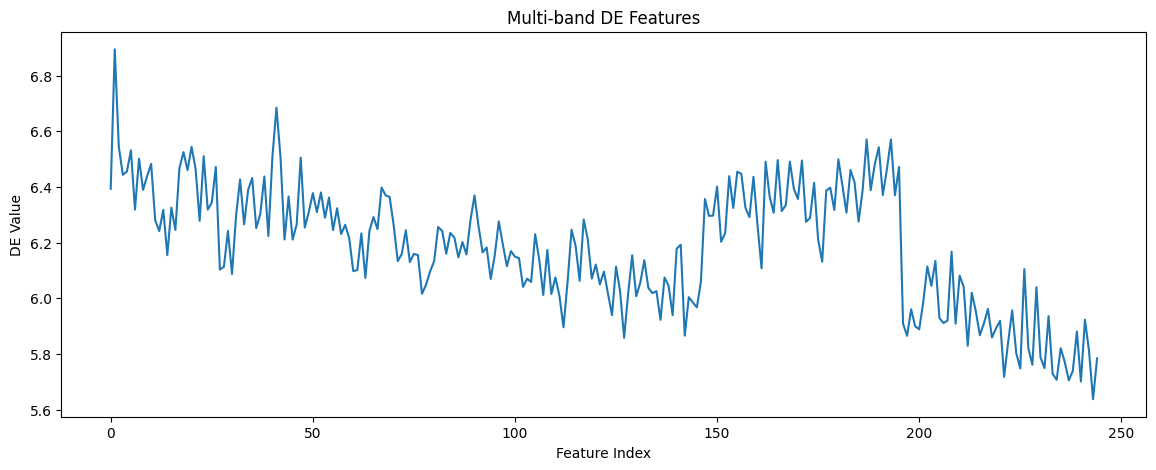


Training Samples: 67
Testing Samples: 17

CLASSIFICATION RESULTS

Accuracy: 0.8235294117647058

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.80      0.89      0.84         9

    accuracy                           0.82        17
   macro avg       0.83      0.82      0.82        17
weighted avg       0.83      0.82      0.82        17


Confusion Matrix:

[[6 2]
 [1 8]]


In [20]:
# =========================================================
# MULTI-BAND DIFFERENTIAL ENTROPY EEG CLASSIFICATION
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================================================
# DATASET PATHS
# =========================================================

BASE_PATH = "/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia"

SCH_PATH = os.path.join(BASE_PATH, "sch")
NORM_PATH = os.path.join(BASE_PATH, "norm")

# =========================================================
# READ EEG FILE
# =========================================================

def read_eeg_file(filepath):

    try:
        data = np.loadtxt(filepath)
        return data

    except:
        return None

# =========================================================
# BANDPASS FILTER
# =========================================================

def butter_bandpass(lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    return b, a


def bandpass_filter(data, lowcut, highcut, fs=250):

    b, a = butter_bandpass(lowcut, highcut, fs)

    filtered = filtfilt(b, a, data)

    return filtered

# =========================================================
# DIFFERENTIAL ENTROPY
# =========================================================

def differential_entropy(signal):

    variance = np.var(signal)

    if variance <= 0:
        variance = 1e-8

    de = 0.5 * np.log(2 * np.pi * np.e * variance)

    return de

# =========================================================
# EEG BANDS
# =========================================================

bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 40)
}

# =========================================================
# PARAMETERS
# =========================================================

window_size = 2500

# =========================================================
# BUILD DATASET
# =========================================================

X = []
y = []

# =========================================================
# PROCESS FUNCTION
# =========================================================

def process_subject(filepath):

    eeg = read_eeg_file(filepath)

    if eeg is None:
        return None

    eeg = eeg.flatten()

    subject_features = []

    # ---------------------------------
    # PROCESS EACH EEG BAND
    # ---------------------------------

    for band_name, (lowcut, highcut) in bands.items():

        filtered = bandpass_filter(
            eeg,
            lowcut=lowcut,
            highcut=highcut
        )

        # Segmentation
        for i in range(0, len(filtered) - window_size, window_size):

            segment = filtered[i:i+window_size]

            de = differential_entropy(segment)

            subject_features.append(de)

    return subject_features

# =========================================================
# SCHIZOPHRENIA SUBJECTS
# =========================================================

for file in os.listdir(SCH_PATH):

    filepath = os.path.join(SCH_PATH, file)

    features = process_subject(filepath)

    if features is not None:

        X.append(features)

        y.append(1)

# =========================================================
# HEALTHY SUBJECTS
# =========================================================

for file in os.listdir(NORM_PATH):

    filepath = os.path.join(NORM_PATH, file)

    features = process_subject(filepath)

    if features is not None:

        X.append(features)

        y.append(0)

# =========================================================
# NUMPY CONVERSION
# =========================================================

X = np.array(X)
y = np.array(y)

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(14,5))

plt.plot(X[0])

plt.title("Multi-band DE Features")

plt.xlabel("Feature Index")
plt.ylabel("DE Value")

plt.show()

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# =========================================================
# SVM MODEL
# =========================================================

model = Pipeline([
    ('scaler', StandardScaler()),

    ('svm', SVC(
        kernel='rbf',
        C=10,
        gamma='scale'
    ))
])

# =========================================================
# TRAIN
# =========================================================

model.fit(X_train, y_train)

# =========================================================
# PREDICT
# =========================================================

y_pred = model.predict(X_test)

# =========================================================
# EVALUATION
# =========================================================

acc = accuracy_score(y_test, y_pred)

print("\n=====================")
print("CLASSIFICATION RESULTS")
print("=====================")

print("\nAccuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

In [21]:
# =========================================================
# RANDOM FOREST CLASSIFIER
# =========================================================

from sklearn.ensemble import RandomForestClassifier

# =========================================================
# RF MODEL
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

# =========================================================
# TRAIN RF
# =========================================================

rf_model.fit(X_train, y_train)

# =========================================================
# PREDICT
# =========================================================

rf_pred = rf_model.predict(X_test)

# =========================================================
# EVALUATION
# =========================================================

rf_acc = accuracy_score(y_test, rf_pred)

print("\n=====================")
print("RANDOM FOREST RESULTS")
print("=====================")

print("\nAccuracy:", rf_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))


RANDOM FOREST RESULTS

Accuracy: 0.8235294117647058

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.80      0.89      0.84         9

    accuracy                           0.82        17
   macro avg       0.83      0.82      0.82        17
weighted avg       0.83      0.82      0.82        17


Confusion Matrix:

[[6 2]
 [1 8]]


In [22]:
# =========================================================
# XGBOOST CLASSIFIER
# =========================================================

!pip install xgboost -q

from xgboost import XGBClassifier

# =========================================================
# XGBOOST MODEL
# =========================================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# =========================================================
# TRAIN MODEL
# =========================================================

xgb_model.fit(X_train, y_train)

# =========================================================
# PREDICTION
# =========================================================

xgb_pred = xgb_model.predict(X_test)

# =========================================================
# EVALUATION
# =========================================================

xgb_acc = accuracy_score(y_test, xgb_pred)

print("\n=====================")
print("XGBOOST RESULTS")
print("=====================")

print("\nAccuracy:", xgb_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, xgb_pred))


XGBOOST RESULTS

Accuracy: 0.8235294117647058

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.80      0.89      0.84         9

    accuracy                           0.82        17
   macro avg       0.83      0.82      0.82        17
weighted avg       0.83      0.82      0.82        17


Confusion Matrix:

[[6 2]
 [1 8]]


In [23]:
!pip install tensorflow -q

In [24]:
# =========================================================
# 1D CNN FOR SCHIZOPHRENIA EEG CLASSIFICATION
# =========================================================

import os
import numpy as np

from scipy.signal import butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical

# =========================================================
# DATASET PATHS
# =========================================================

BASE_PATH = "/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia"

SCH_PATH = os.path.join(BASE_PATH, "sch")
NORM_PATH = os.path.join(BASE_PATH, "norm")

# =========================================================
# EEG FILE READER
# =========================================================

def read_eeg_file(filepath):

    try:
        data = np.loadtxt(filepath)
        return data

    except:
        return None

# =========================================================
# BANDPASS FILTER
# =========================================================

def butter_bandpass(lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    return b, a


def bandpass_filter(data, lowcut=0.5, highcut=40, fs=250):

    b, a = butter_bandpass(lowcut, highcut, fs)

    filtered = filtfilt(b, a, data)

    return filtered

# =========================================================
# PARAMETERS
# =========================================================

window_size = 2500

X = []
y = []

# =========================================================
# PROCESS SUBJECT FUNCTION
# =========================================================

def process_subject(filepath, label):

    eeg = read_eeg_file(filepath)

    if eeg is None:
        return

    eeg = eeg.flatten()

    eeg = bandpass_filter(eeg)

    # ------------------------------------
    # CREATE EEG SEGMENTS
    # ------------------------------------

    for i in range(0, len(eeg) - window_size, window_size):

        segment = eeg[i:i+window_size]

        X.append(segment)

        y.append(label)

# =========================================================
# SCHIZOPHRENIA SUBJECTS
# =========================================================

for file in os.listdir(SCH_PATH):

    filepath = os.path.join(SCH_PATH, file)

    process_subject(filepath, 1)

# =========================================================
# HEALTHY SUBJECTS
# =========================================================

for file in os.listdir(NORM_PATH):

    filepath = os.path.join(NORM_PATH, file)

    process_subject(filepath, 0)

# =========================================================
# NUMPY CONVERSION
# =========================================================

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

# =========================================================
# NORMALIZATION
# =========================================================

X = (X - np.mean(X)) / np.std(X)

# CNN input shape
X = X.reshape(X.shape[0], X.shape[1], 1)

print("CNN Input Shape:", X.shape)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================================================
# CNN MODEL
# =========================================================

model = Sequential()

# ---------------------------
# CONV BLOCK 1
# ---------------------------

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(window_size,1)
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(pool_size=2))

# ---------------------------
# CONV BLOCK 2
# ---------------------------

model.add(
    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(pool_size=2))

# ---------------------------
# CLASSIFICATION
# ---------------------------

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

# =========================================================
# COMPILE MODEL
# =========================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================================================
# TRAIN MODEL
# =========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# =========================================================
# PREDICTION
# =========================================================

y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

# =========================================================
# EVALUATION
# =========================================================

acc = accuracy_score(y_test, y_pred)

print("\n=====================")
print("CNN RESULTS")
print("=====================")

print("\nAccuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

2026-05-07 11:30:50.593753: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778153450.821264      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778153450.887506      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778153451.432486      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778153451.432530      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778153451.432533      23 computation_placer.cc:177] computation placer alr

X Shape: (4116, 2500)
y Shape: (4116,)
CNN Input Shape: (4116, 2500, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778153475.237450      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778153475.243401      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2496, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2496, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1248, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1244, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1244, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 622, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 39808)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,095,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Epoch 1/20


I0000 00:00:1778153478.798289      93 service.cc:152] XLA service 0x7ced98008300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778153478.798352      93 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778153478.798359      93 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778153479.272483      93 cuda_dnn.cc:529] Loaded cuDNN version 91002


13/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5063 - loss: 2.8388

I0000 00:00:1778153482.625333      93 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.5338 - loss: 1.9084 - val_accuracy: 0.5182 - val_loss: 5.7725
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6509 - loss: 0.5886 - val_accuracy: 0.5182 - val_loss: 9.4898
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7250 - loss: 0.5191 - val_accuracy: 0.5394 - val_loss: 8.8497
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7829 - loss: 0.4360 - val_accuracy: 0.6333 - val_loss: 3.7226
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8095 - loss: 0.3790 - val_accuracy: 0.5879 - val_loss: 2.0585
Epoch 6/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8344 - loss: 0.3299 - val_accuracy: 0.5758 - val_loss: 0.9575
Epoch 7/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8644 - loss: 0.2822 - val_accuracy: 0.6182 - val_loss: 0.8462
Epoch 8/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8556 - loss: 0.2632 - val_accuracy: 0.5485 - val_loss: 0

In [25]:
# =========================================================
# LSTM ON MULTI-BAND DE FEATURES
# =========================================================

import os
import numpy as np

from scipy.signal import butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

# =========================================================
# DATASET PATHS
# =========================================================

BASE_PATH = "/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia"

SCH_PATH = os.path.join(BASE_PATH, "sch")
NORM_PATH = os.path.join(BASE_PATH, "norm")

# =========================================================
# EEG FILE READER
# =========================================================

def read_eeg_file(filepath):

    try:
        data = np.loadtxt(filepath)
        return data

    except:
        return None

# =========================================================
# BANDPASS FILTER
# =========================================================

def butter_bandpass(lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    return b, a


def bandpass_filter(data, lowcut, highcut, fs=250):

    b, a = butter_bandpass(lowcut, highcut, fs)

    filtered = filtfilt(b, a, data)

    return filtered

# =========================================================
# DIFFERENTIAL ENTROPY
# =========================================================

def differential_entropy(signal):

    variance = np.var(signal)

    if variance <= 0:
        variance = 1e-8

    de = 0.5 * np.log(2 * np.pi * np.e * variance)

    return de

# =========================================================
# EEG BANDS
# =========================================================

bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 40)
}

# =========================================================
# PARAMETERS
# =========================================================

window_size = 2500

X = []
y = []

# =========================================================
# PROCESS SUBJECT
# =========================================================

def process_subject(filepath):

    eeg = read_eeg_file(filepath)

    if eeg is None:
        return None

    eeg = eeg.flatten()

    subject_features = []

    # ---------------------------------
    # PROCESS EACH EEG BAND
    # ---------------------------------

    band_features = []

    for band_name, (lowcut, highcut) in bands.items():

        filtered = bandpass_filter(
            eeg,
            lowcut,
            highcut
        )

        temp_features = []

        for i in range(0, len(filtered) - window_size, window_size):

            segment = filtered[i:i+window_size]

            de = differential_entropy(segment)

            temp_features.append(de)

        band_features.append(temp_features)

    # Convert:
    # (5 bands, 49 segments)
    # ->
    # (49 segments, 5 bands)

    band_features = np.array(band_features).T

    return band_features

# =========================================================
# SCHIZOPHRENIA SUBJECTS
# =========================================================

for file in os.listdir(SCH_PATH):

    filepath = os.path.join(SCH_PATH, file)

    features = process_subject(filepath)

    if features is not None:

        X.append(features)

        y.append(1)

# =========================================================
# HEALTHY SUBJECTS
# =========================================================

for file in os.listdir(NORM_PATH):

    filepath = os.path.join(NORM_PATH, file)

    features = process_subject(filepath)

    if features is not None:

        X.append(features)

        y.append(0)

# =========================================================
# NUMPY CONVERSION
# =========================================================

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

# Expected:
# (84, 49, 5)

# =========================================================
# NORMALIZATION
# =========================================================

X_mean = np.mean(X)
X_std = np.std(X)

X = (X - X_mean) / X_std

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================================================
# LSTM MODEL
# =========================================================

model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(49,5),
        return_sequences=False
    )
)

model.add(BatchNormalization())

model.add(Dropout(0.5))

model.add(Dense(32, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================================================
# TRAIN
# =========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.1,
    verbose=1
)

# =========================================================
# PREDICT
# =========================================================

y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

# =========================================================
# EVALUATION
# =========================================================

acc = accuracy_score(y_test, y_pred)

print("\n=====================")
print("LSTM RESULTS")
print("=====================")

print("\nAccuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

X Shape: (84, 49, 5)
y Shape: (84,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,161 (78.75 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.4537 - loss: 1.0452 - val_accuracy: 0.5714 - val_loss: 0.6769
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5436 - loss: 0.8311 - val_accuracy: 0.5714 - val_loss: 0.6786
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6415 - loss: 0.7944 - val_accuracy: 0.5714 - val_loss: 0.6827
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7079 - loss: 0.6573 - val_accuracy: 0.8571 - val_loss: 0.6858
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5870 - loss: 0.6839 - val_accuracy: 0.7143 - val_loss: 0.6879
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6658 - loss: 0.7702 - val_accuracy: 0.5714 - val_loss: 0.6928
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6534 - loss: 0.7178 - val_accuracy: 0.4286 - val_loss: 0.6983
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6724 - loss: 0.6436 - val_accuracy: 0.4286 - val_loss: 0.6998


In [26]:
# =========================================================
# TRANSFORMER FOR SCHIZOPHRENIA EEG CLASSIFICATION
# =========================================================

import os
import numpy as np

from scipy.signal import butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D
)

from tensorflow.keras.models import Model

# =========================================================
# DATASET PATHS
# =========================================================

BASE_PATH = "/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia"

SCH_PATH = os.path.join(BASE_PATH, "sch")
NORM_PATH = os.path.join(BASE_PATH, "norm")

# =========================================================
# EEG FILE READER
# =========================================================

def read_eeg_file(filepath):

    try:
        data = np.loadtxt(filepath)
        return data

    except:
        return None

# =========================================================
# BANDPASS FILTER
# =========================================================

def butter_bandpass(lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    return b, a


def bandpass_filter(data, lowcut, highcut, fs=250):

    b, a = butter_bandpass(lowcut, highcut, fs)

    filtered = filtfilt(b, a, data)

    return filtered

# =========================================================
# DIFFERENTIAL ENTROPY
# =========================================================

def differential_entropy(signal):

    variance = np.var(signal)

    if variance <= 0:
        variance = 1e-8

    de = 0.5 * np.log(2 * np.pi * np.e * variance)

    return de

# =========================================================
# EEG BANDS
# =========================================================

bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 40)
}

# =========================================================
# PARAMETERS
# =========================================================

window_size = 2500

X = []
y = []

# =========================================================
# PROCESS SUBJECT
# =========================================================

def process_subject(filepath):

    eeg = read_eeg_file(filepath)

    if eeg is None:
        return None

    eeg = eeg.flatten()

    band_features = []

    for band_name, (lowcut, highcut) in bands.items():

        filtered = bandpass_filter(
            eeg,
            lowcut,
            highcut
        )

        temp_features = []

        for i in range(0, len(filtered) - window_size, window_size):

            segment = filtered[i:i+window_size]

            de = differential_entropy(segment)

            temp_features.append(de)

        band_features.append(temp_features)

    # (5,49) -> (49,5)
    band_features = np.array(band_features).T

    return band_features

# =========================================================
# SCHIZOPHRENIA SUBJECTS
# =========================================================

for file in os.listdir(SCH_PATH):

    filepath = os.path.join(SCH_PATH, file)

    features = process_subject(filepath)

    if features is not None:

        X.append(features)

        y.append(1)

# =========================================================
# HEALTHY SUBJECTS
# =========================================================

for file in os.listdir(NORM_PATH):

    filepath = os.path.join(NORM_PATH, file)

    features = process_subject(filepath)

    if features is not None:

        X.append(features)

        y.append(0)

# =========================================================
# NUMPY CONVERSION
# =========================================================

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

# =========================================================
# NORMALIZATION
# =========================================================

X_mean = np.mean(X)
X_std = np.std(X)

X = (X - X_mean) / X_std

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================================================
# TRANSFORMER BLOCK
# =========================================================

def transformer_block(inputs, head_size, num_heads, ff_dim, dropout=0):

    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = Dropout(dropout)(x)

    x = LayerNormalization(epsilon=1e-6)(x + inputs)

    ff = Dense(ff_dim, activation="relu")(x)

    ff = Dropout(dropout)(ff)

    ff = Dense(inputs.shape[-1])(ff)

    return LayerNormalization(epsilon=1e-6)(ff + x)

# =========================================================
# BUILD TRANSFORMER MODEL
# =========================================================

inputs = Input(shape=(49,5))

x = transformer_block(
    inputs,
    head_size=32,
    num_heads=2,
    ff_dim=64,
    dropout=0.2
)

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation='relu')(x)

x = Dropout(0.4)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================================================
# TRAIN
# =========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.1,
    verbose=1
)

# =========================================================
# PREDICT
# =========================================================

y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

# =========================================================
# EVALUATION
# =========================================================

acc = accuracy_score(y_test, y_pred)

print("\n=====================")
print("TRANSFORMER RESULTS")
print("=====================")

print("\nAccuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

X Shape: (84, 49, 5)
y Shape: (84,)


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 49, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 5)     │      1,477 │ input_layer_2[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 49, 5)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 5)     │          0 │ dropout_4[0][0],  │
│                     │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 49, 5)     │         10 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 49, 64)    │        384 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 49, 64)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 49, 5)     │        325 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 49, 5)     │          0 │ dense_5[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 5)     │         10 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 5)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │        384 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,655 (10.37 KB)

 Trainable params: 2,655 (10.37 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 716ms/step - accuracy: 0.5910 - loss: 0.6973 - val_accuracy: 0.4286 - val_loss: 0.7492
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5611 - loss: 0.7030 - val_accuracy: 0.2857 - val_loss: 0.7411
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7264 - loss: 0.6283 - val_accuracy: 0.2857 - val_loss: 0.7414
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5831 - loss: 0.6717 - val_accuracy: 0.2857 - val_loss: 0.7450
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6012 - loss: 0.6920 - val_accuracy: 0.2857 - val_loss: 0.7484
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6818 - loss: 0.6505 - val_accuracy: 0.2857 - val_loss: 0.7540
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7013 - loss: 0.6456 - val_accuracy: 0.4286 - val_loss: 0.7614
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7056 - loss: 0.6164 - val_accuracy: 0.4286 - val_loss: 0.773

In [27]:
# =========================================================
# CNN + LSTM FOR SCHIZOPHRENIA EEG CLASSIFICATION
# =========================================================

import os
import numpy as np

from scipy.signal import butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

# =========================================================
# DATASET PATHS
# =========================================================

BASE_PATH = "/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia"

SCH_PATH = os.path.join(BASE_PATH, "sch")
NORM_PATH = os.path.join(BASE_PATH, "norm")

# =========================================================
# EEG FILE READER
# =========================================================

def read_eeg_file(filepath):

    try:
        data = np.loadtxt(filepath)
        return data

    except:
        return None

# =========================================================
# BANDPASS FILTER
# =========================================================

def butter_bandpass(lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    return b, a


def bandpass_filter(data, lowcut=0.5, highcut=40, fs=250):

    b, a = butter_bandpass(lowcut, highcut, fs)

    filtered = filtfilt(b, a, data)

    return filtered

# =========================================================
# PARAMETERS
# =========================================================

window_size = 2500

X = []
y = []

# =========================================================
# PROCESS SUBJECT
# =========================================================

def process_subject(filepath, label):

    eeg = read_eeg_file(filepath)

    if eeg is None:
        return

    eeg = eeg.flatten()

    eeg = bandpass_filter(eeg)

    # ---------------------------------
    # CREATE EEG SEGMENTS
    # ---------------------------------

    for i in range(0, len(eeg) - window_size, window_size):

        segment = eeg[i:i+window_size]

        X.append(segment)

        y.append(label)

# =========================================================
# SCHIZOPHRENIA SUBJECTS
# =========================================================

for file in os.listdir(SCH_PATH):

    filepath = os.path.join(SCH_PATH, file)

    process_subject(filepath, 1)

# =========================================================
# HEALTHY SUBJECTS
# =========================================================

for file in os.listdir(NORM_PATH):

    filepath = os.path.join(NORM_PATH, file)

    process_subject(filepath, 0)

# =========================================================
# NUMPY CONVERSION
# =========================================================

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

# =========================================================
# NORMALIZATION
# =========================================================

X = (X - np.mean(X)) / np.std(X)

# CNN input
X = X.reshape(X.shape[0], X.shape[1], 1)

print("CNN-LSTM Input Shape:", X.shape)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================================================
# CNN-LSTM MODEL
# =========================================================

model = Sequential()

# ------------------------------------------------
# CNN BLOCK 1
# ------------------------------------------------

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(window_size,1)
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(pool_size=2))

# ------------------------------------------------
# CNN BLOCK 2
# ------------------------------------------------

model.add(
    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(pool_size=2))

# =========================================================
# LSTM BLOCK
# =========================================================

model.add(
    LSTM(
        64,
        return_sequences=False
    )
)

# =========================================================
# CLASSIFICATION BLOCK
# =========================================================

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================================================
# TRAIN
# =========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# =========================================================
# PREDICT
# =========================================================

y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

# =========================================================
# EVALUATION
# =========================================================

acc = accuracy_score(y_test, y_pred)

print("\n=====================")
print("CNN-LSTM RESULTS")
print("=====================")

print("\nAccuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

X Shape: (4116, 2500)
y Shape: (4116,)
CNN-LSTM Input Shape: (4116, 2500, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 2496, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2496, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1248, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1244, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1244, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 622, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,129 (188.00 KB)

 Trainable params: 47,937 (187.25 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5321 - loss: 0.6898 - val_accuracy: 0.5424 - val_loss: 0.6773
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6019 - loss: 0.6672 - val_accuracy: 0.6000 - val_loss: 0.6647
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6276 - loss: 0.6559 - val_accuracy: 0.6303 - val_loss: 0.6552
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6326 - loss: 0.6482 - val_accuracy: 0.6364 - val_loss: 0.6453
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6265 - loss: 0.6458 - val_accuracy: 0.6364 - val_loss: 0.6315
Epoch 6/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6510 - loss: 0.6315 - val_accuracy: 0.6242 - val_loss: 0.6453
Epoch 7/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6386 - loss: 0.6270 - val_accuracy: 0.6182 - val_loss: 0.6705
Epoch 8/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6200 - loss: 0.6560 - val_accuracy: 0.6364 - v

In [28]:
# =========================================================
# DE + PSD FEATURE FUSION FOR SCHIZOPHRENIA EEG
# =========================================================

import os
import numpy as np

from scipy.signal import butter, filtfilt, welch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================================================
# DATASET PATHS
# =========================================================

BASE_PATH = "/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia"

SCH_PATH = os.path.join(BASE_PATH, "sch")
NORM_PATH = os.path.join(BASE_PATH, "norm")

# =========================================================
# EEG FILE READER
# =========================================================

def read_eeg_file(filepath):

    try:
        data = np.loadtxt(filepath)
        return data

    except:
        return None

# =========================================================
# BANDPASS FILTER
# =========================================================

def butter_bandpass(lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    return b, a


def bandpass_filter(data, lowcut, highcut, fs=250):

    b, a = butter_bandpass(lowcut, highcut, fs)

    filtered = filtfilt(b, a, data)

    return filtered

# =========================================================
# DIFFERENTIAL ENTROPY
# =========================================================

def differential_entropy(signal):

    variance = np.var(signal)

    if variance <= 0:
        variance = 1e-8

    de = 0.5 * np.log(2 * np.pi * np.e * variance)

    return de

# =========================================================
# PSD FEATURE
# =========================================================

def compute_psd(signal, fs=250):

    freqs, psd = welch(signal, fs=fs)

    return np.mean(psd)

# =========================================================
# EEG BANDS
# =========================================================

bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 40)
}

# =========================================================
# PARAMETERS
# =========================================================

window_size = 2500

X = []
y = []

# =========================================================
# PROCESS SUBJECT
# =========================================================

def process_subject(filepath):

    eeg = read_eeg_file(filepath)

    if eeg is None:
        return None

    eeg = eeg.flatten()

    subject_features = []

    # -----------------------------------------
    # PROCESS EACH EEG BAND
    # -----------------------------------------

    for band_name, (lowcut, highcut) in bands.items():

        filtered = bandpass_filter(
            eeg,
            lowcut,
            highcut
        )

        # -------------------------------------
        # SEGMENT EEG
        # -------------------------------------

        for i in range(0, len(filtered) - window_size, window_size):

            segment = filtered[i:i+window_size]

            # ---------------------------------
            # DE FEATURE
            # ---------------------------------

            de = differential_entropy(segment)

            # ---------------------------------
            # PSD FEATURE
            # ---------------------------------

            psd = compute_psd(segment)

            # ---------------------------------
            # FEATURE FUSION
            # ---------------------------------

            subject_features.append(de)
            subject_features.append(psd)

    return subject_features

# =========================================================
# SCHIZOPHRENIA SUBJECTS
# =========================================================

for file in os.listdir(SCH_PATH):

    filepath = os.path.join(SCH_PATH, file)

    features = process_subject(filepath)

    if features is not None:

        X.append(features)

        y.append(1)

# =========================================================
# HEALTHY SUBJECTS
# =========================================================

for file in os.listdir(NORM_PATH):

    filepath = os.path.join(NORM_PATH, file)

    features = process_subject(filepath)

    if features is not None:

        X.append(features)

        y.append(0)

# =========================================================
# NUMPY CONVERSION
# =========================================================

X = np.array(X)
y = np.array(y)

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================================================
# SVM MODEL
# =========================================================

model = Pipeline([
    ('scaler', StandardScaler()),

    ('svm', SVC(
        kernel='rbf',
        C=10,
        gamma='scale'
    ))
])

# =========================================================
# TRAIN
# =========================================================

model.fit(X_train, y_train)

# =========================================================
# PREDICT
# =========================================================

y_pred = model.predict(X_test)

# =========================================================
# EVALUATION
# =========================================================

acc = accuracy_score(y_test, y_pred)

print("\n=====================")
print("DE + PSD RESULTS")
print("=====================")

print("\nAccuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Feature Shape: (84, 490)
Label Shape: (84,)

DE + PSD RESULTS

Accuracy: 0.7647058823529411

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.75      0.75         8
           1       0.78      0.78      0.78         9

    accuracy                           0.76        17
   macro avg       0.76      0.76      0.76        17
weighted avg       0.76      0.76      0.76        17


Confusion Matrix:

[[6 2]
 [2 7]]


In [29]:
# =========================================================
# LOSO VALIDATION
# MULTI-BAND DE + SVM
# =========================================================

import os
import numpy as np

from scipy.signal import butter, filtfilt

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import LeaveOneOut

# =========================================================
# DATASET PATHS
# =========================================================

BASE_PATH = "/kaggle/input/datasets/kacharepramod/eeg-schizophrenia/Schizophrenia"

SCH_PATH = os.path.join(BASE_PATH, "sch")
NORM_PATH = os.path.join(BASE_PATH, "norm")

# =========================================================
# EEG FILE READER
# =========================================================

def read_eeg_file(filepath):

    try:
        data = np.loadtxt(filepath)
        return data

    except:
        return None

# =========================================================
# BANDPASS FILTER
# =========================================================

def butter_bandpass(lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    return b, a


def bandpass_filter(data, lowcut, highcut, fs=250):

    b, a = butter_bandpass(lowcut, highcut, fs)

    filtered = filtfilt(b, a, data)

    return filtered

# =========================================================
# DIFFERENTIAL ENTROPY
# =========================================================

def differential_entropy(signal):

    variance = np.var(signal)

    if variance <= 0:
        variance = 1e-8

    de = 0.5 * np.log(2 * np.pi * np.e * variance)

    return de

# =========================================================
# EEG BANDS
# =========================================================

bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 40)
}

# =========================================================
# PARAMETERS
# =========================================================

window_size = 2500

X = []
y = []

# =========================================================
# PROCESS SUBJECT
# =========================================================

def process_subject(filepath):

    eeg = read_eeg_file(filepath)

    if eeg is None:
        return None

    eeg = eeg.flatten()

    subject_features = []

    # ---------------------------------
    # PROCESS EACH EEG BAND
    # ---------------------------------

    for band_name, (lowcut, highcut) in bands.items():

        filtered = bandpass_filter(
            eeg,
            lowcut,
            highcut
        )

        # Segmentation
        for i in range(0, len(filtered) - window_size, window_size):

            segment = filtered[i:i+window_size]

            de = differential_entropy(segment)

            subject_features.append(de)

    return subject_features

# =========================================================
# SCHIZOPHRENIA SUBJECTS
# =========================================================

for file in os.listdir(SCH_PATH):

    filepath = os.path.join(SCH_PATH, file)

    features = process_subject(filepath)

    if features is not None:

        X.append(features)

        y.append(1)

# =========================================================
# HEALTHY SUBJECTS
# =========================================================

for file in os.listdir(NORM_PATH):

    filepath = os.path.join(NORM_PATH, file)

    features = process_subject(filepath)

    if features is not None:

        X.append(features)

        y.append(0)

# =========================================================
# NUMPY CONVERSION
# =========================================================

X = np.array(X)
y = np.array(y)

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

# =========================================================
# LOSO VALIDATION
# =========================================================

loo = LeaveOneOut()

all_preds = []
all_true = []

# =========================================================
# LOSO LOOP
# =========================================================

for train_idx, test_idx in loo.split(X):

    X_train, X_test = X[train_idx], X[test_idx]

    y_train, y_test = y[train_idx], y[test_idx]

    # -----------------------------------------
    # SVM PIPELINE
    # -----------------------------------------

    model = Pipeline([
        ('scaler', StandardScaler()),

        ('svm', SVC(
            kernel='rbf',
            C=10,
            gamma='scale'
        ))
    ])

    # Train
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    all_preds.extend(pred)

    all_true.extend(y_test)

# =========================================================
# FINAL EVALUATION
# =========================================================

acc = accuracy_score(all_true, all_preds)

print("\n=====================")
print("LOSO RESULTS")
print("=====================")

print("\nAccuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(all_true, all_preds))

print("\nConfusion Matrix:\n")
print(confusion_matrix(all_true, all_preds))

Feature Shape: (84, 245)
Label Shape: (84,)

LOSO RESULTS

Accuracy: 0.7857142857142857

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.77      0.77        39
           1       0.80      0.80      0.80        45

    accuracy                           0.79        84
   macro avg       0.78      0.78      0.78        84
weighted avg       0.79      0.79      0.79        84


Confusion Matrix:

[[30  9]
 [ 9 36]]


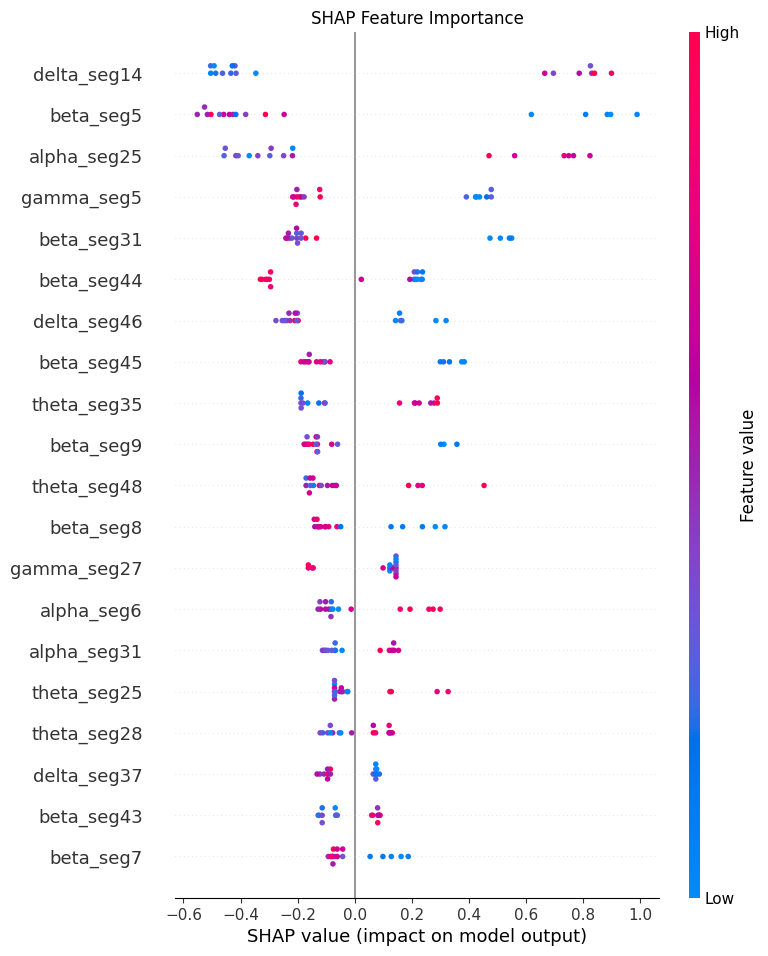

In [30]:
# =========================================================
# SHAP EXPLAINABILITY ANALYSIS
# =========================================================

import shap
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================================================
# XGBOOST MODEL
# =========================================================

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# =========================================================
# TRAIN MODEL
# =========================================================

model.fit(X_train, y_train)

# =========================================================
# SHAP EXPLAINER
# =========================================================

explainer = shap.TreeExplainer(model)

# =========================================================
# COMPUTE SHAP VALUES
# =========================================================

shap_values = explainer.shap_values(X_test)

# =========================================================
# FEATURE NAMES
# =========================================================

feature_names = []

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

for band in bands:

    for seg in range(49):

        feature_names.append(f"{band}_seg{seg+1}")

# =========================================================
# SHAP SUMMARY PLOT
# =========================================================

plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance")

plt.show()